# Job Market Intelligence — Application Pipeline Analysis

**Author:** Xiao Long  
**Updated:** 2026-04-21  

End-to-end analysis of my DS/DA job search pipeline: status breakdown, application cadence, rejection patterns, location distribution, and LinkedIn outreach tracking. Data sourced from a SQLite database populated from real applications.

**Dataset:** 59 tracked applications (Feb–Apr 2026)

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime, date

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

conn = sqlite3.connect('../data/jobs.db')

df = pd.read_sql_query("""
    SELECT
        j.id, j.date_found, j.company, j.role, j.location, j.remote,
        a.date_applied, a.app_status, a.linkedin_contact, a.linkedin_status
    FROM jobs j
    JOIN applications a ON j.id = a.job_id
""", conn)

conn.close()

df['date_applied'] = pd.to_datetime(df['date_applied'])
df['week'] = df['date_applied'].dt.to_period('W')
df['month'] = df['date_applied'].dt.to_period('M')

print(f"Total applications: {len(df)}")
df.head()

Total applications: 59


,id,date_found,company,role,location,remote,date_applied,app_status,linkedin_contact,linkedin_status,week,month
0,1,2026-02-24,TikTok,Data Engineer Graduate (DPUS - Global Live) - ...,San Jose,0,2026-02-24,rejected,None,None,2026-02-23/2026-03-01,2026-02
1,2,2026-03-12,Microsoft,Applied Scientist: Microsoft AI Development Ac...,Redmond,0,2026-03-12,waiting,None,None,2026-03-09/2026-03-15,2026-03
2,3,2026-03-12,Microsoft,Research Engineer - Generative AI - AI Frontiers,Redmond,0,2026-03-12,rejected,None,None,2026-03-09/2026-03-15,2026-03
3,4,2026-03-12,Meta,Production Engineer (University Grad),California,0,2026-03-12,rejected,None,None,2026-03-09/2026-03-15,2026-03
4,5,2026-03-12,Meta,"Research Engineer, Monetization AI",California,0,2026-03-12,rejected,None,None,2026-03-09/2026-03-15,2026-03


## 1. Overall Status Breakdown

            Count  Pct (%)
app_status                
waiting        42     71.2
rejected       16     27.1
interview       1      1.7


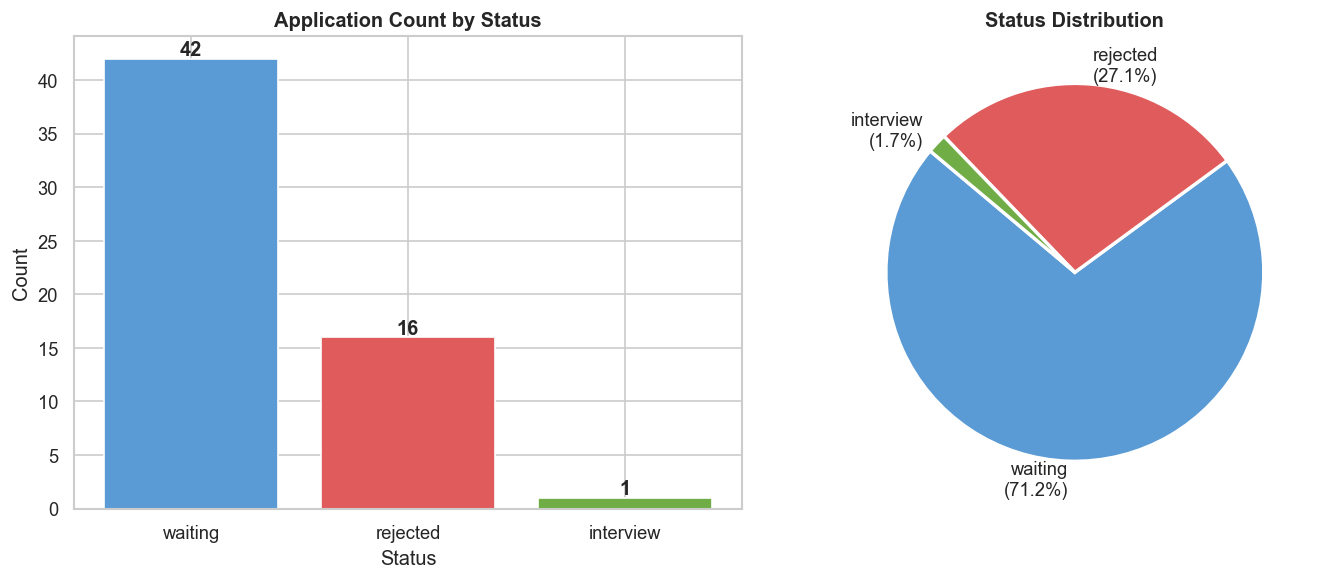

In [2]:
status_counts = df['app_status'].value_counts()
status_pct = (status_counts / len(df) * 100).round(1)

summary = pd.DataFrame({'Count': status_counts, 'Pct (%)': status_pct})
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {'waiting': '#5B9BD5', 'rejected': '#E05C5C', 'interview': '#70AD47'}
bar_colors = [colors.get(s, '#999') for s in status_counts.index]

axes[0].bar(status_counts.index, status_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Application Count by Status', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

pie_colors = [colors.get(s, '#999') for s in status_counts.index]
axes[1].pie(
    status_counts.values,
    labels=[f"{s}\n({pct}%)" for s, pct in zip(status_counts.index, status_pct)],
    colors=pie_colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Status Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/fig1_status_breakdown.png', bbox_inches='tight')
plt.show()

## 2. Application Cadence Over Time

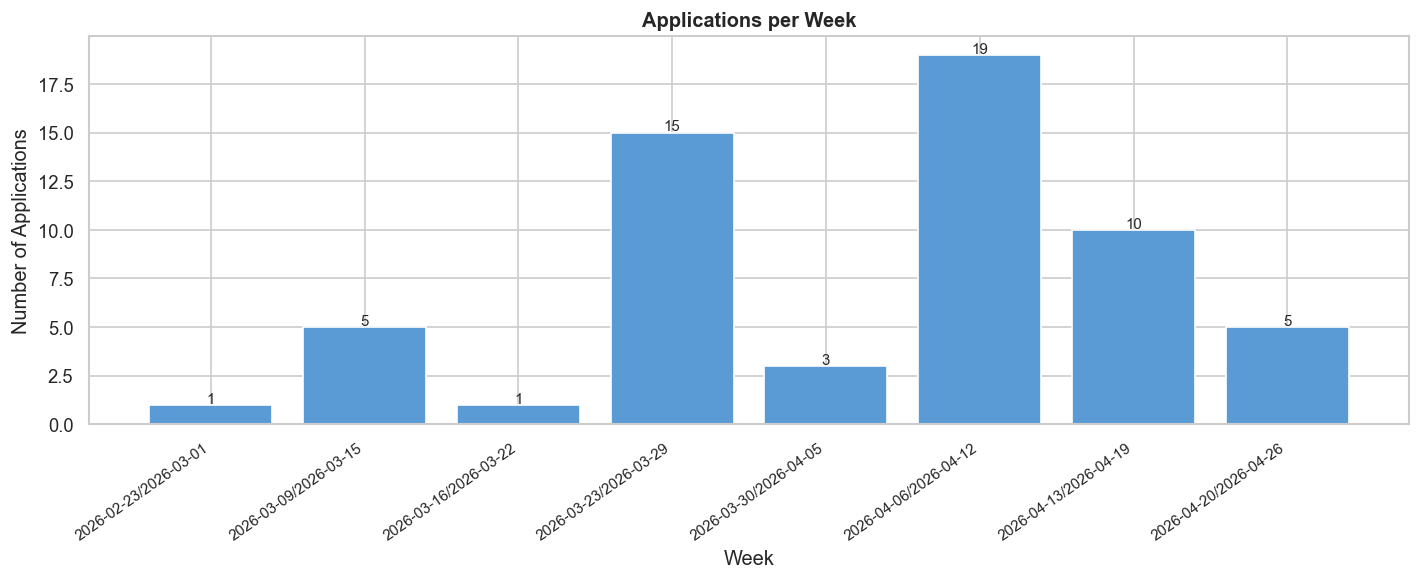

Peak week: 2026-04-06/2026-04-12 (19 apps)


In [3]:
weekly = df.groupby('week').size().reset_index(name='apps')
weekly['week_str'] = weekly['week'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(weekly)), weekly['apps'], color='#5B9BD5', edgecolor='white')
ax.set_xticks(range(len(weekly)))
ax.set_xticklabels(weekly['week_str'], rotation=35, ha='right', fontsize=9)
ax.set_title('Applications per Week', fontweight='bold')
ax.set_ylabel('Number of Applications')
ax.set_xlabel('Week')
for i, v in enumerate(weekly['apps']):
    ax.text(i, v + 0.1, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/fig2_weekly_cadence.png', bbox_inches='tight')
plt.show()
print(f"Peak week: {weekly.loc[weekly['apps'].idxmax(), 'week_str']} ({weekly['apps'].max()} apps)")

## 3. Top Companies by Application Volume

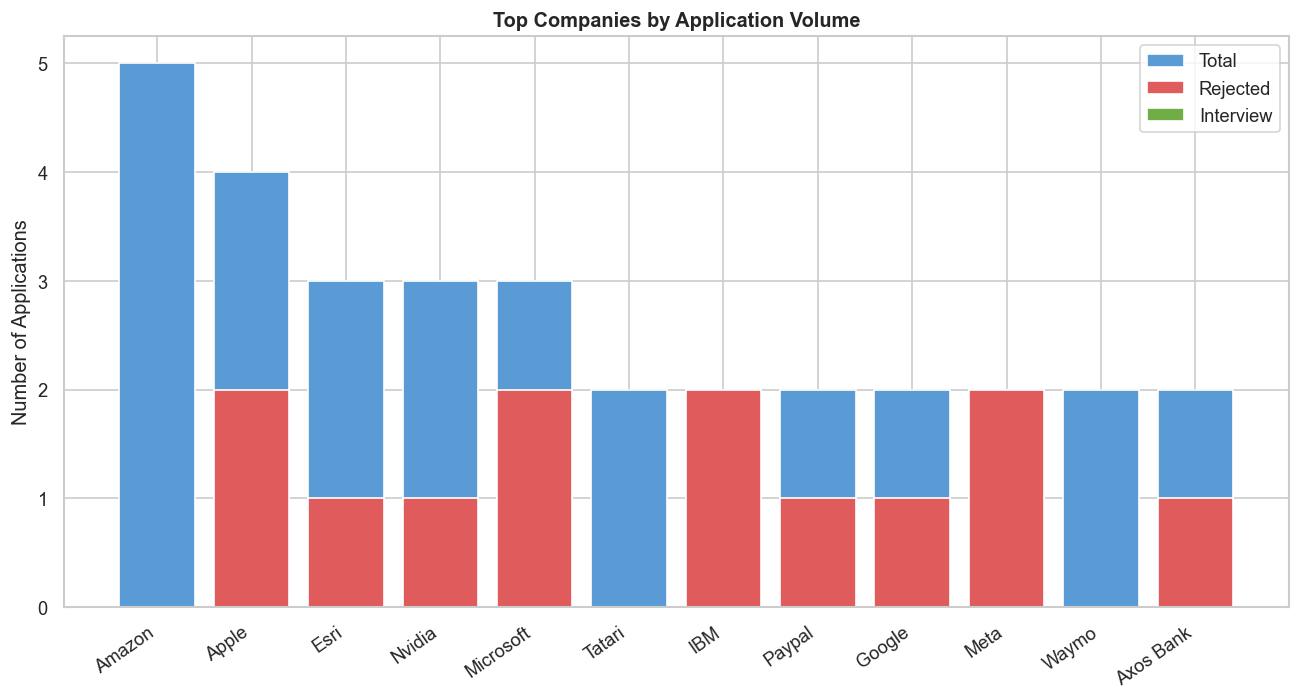

In [4]:
company_stats = df.groupby('company').agg(
    total=('id', 'count'),
    rejected=('app_status', lambda x: (x == 'rejected').sum()),
    interview=('app_status', lambda x: (x == 'interview').sum())
).sort_values('total', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(company_stats))
bars = ax.bar(x, company_stats['total'], color='#5B9BD5', edgecolor='white', label='Total')
ax.bar(x, company_stats['rejected'], color='#E05C5C', edgecolor='white', label='Rejected')
ax.bar(x, company_stats['interview'], color='#70AD47', edgecolor='white', label='Interview')

ax.set_xticks(x)
ax.set_xticklabels(company_stats.index, rotation=35, ha='right')
ax.set_title('Top Companies by Application Volume', fontweight='bold')
ax.set_ylabel('Number of Applications')
ax.legend()

plt.tight_layout()
plt.savefig('../data/fig3_top_companies.png', bbox_inches='tight')
plt.show()

## 4. Location Distribution

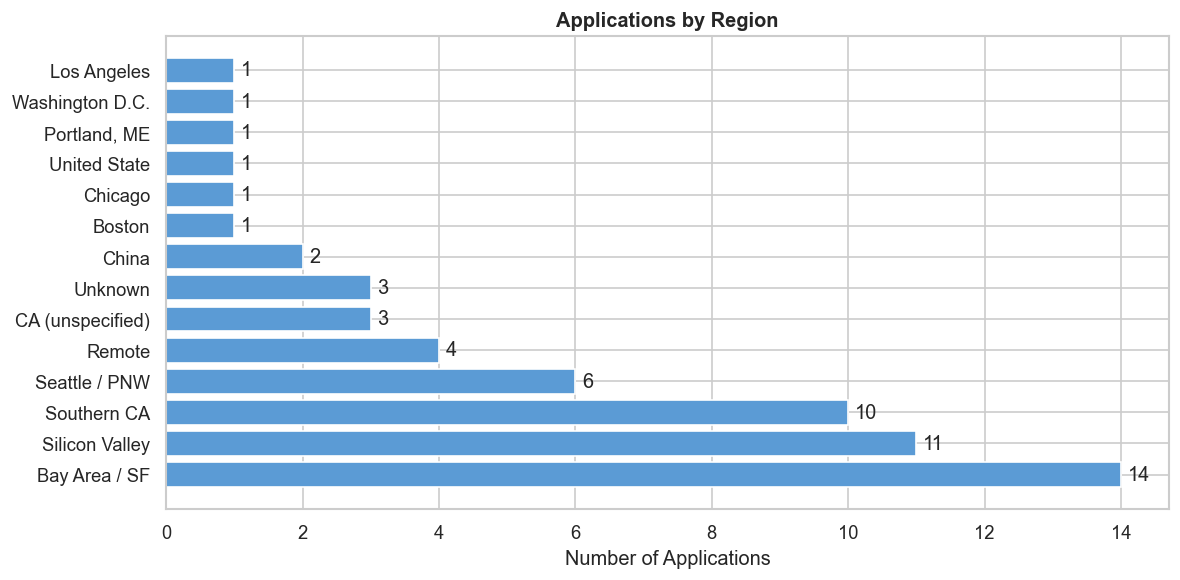

In [5]:
def normalize_location(loc):
    if pd.isna(loc): return 'Unknown'
    loc = loc.strip()
    if 'remote' in loc.lower() or loc == 'Atlanta/remote': return 'Remote'
    if loc in ['San Francisco', 'San Francisco Bay Area', 'Santa Monica',
               'San Bruno', 'Redwood City']: return 'Bay Area / SF'
    if loc in ['San Diego', 'San Diego, CA', 'Orange County HQ',
               'Rancho Cucamonga']: return 'Southern CA'
    if loc in ['Santa Clara', 'Cupertino', 'Mountain View',
               'San Jose']: return 'Silicon Valley'
    if loc in ['California']: return 'CA (unspecified)'
    if loc in ['Redmond', 'Settle', 'Seattle']: return 'Seattle / PNW'
    if loc in ['Los Angeles']: return 'Los Angeles'
    if loc in ['Cambridge']: return 'Boston'
    if loc in ['Beijing']: return 'China'
    return loc

df['region'] = df['location'].apply(normalize_location)
region_counts = df['region'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(region_counts.index, region_counts.values, color='#5B9BD5', edgecolor='white')
ax.set_title('Applications by Region', fontweight='bold')
ax.set_xlabel('Number of Applications')
for i, v in enumerate(region_counts.values):
    ax.text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.savefig('../data/fig4_location_distribution.png', bbox_inches='tight')
plt.show()

## 5. LinkedIn Outreach Tracking

In [6]:
outreach = df[df['linkedin_contact'].notna()].copy()
print(f"Total outreach sent: {len(outreach)}")
print(f"Response rate: {(outreach['linkedin_status'] == 'replied').sum() / len(outreach) * 100:.1f}%")
print()
print(outreach[['company', 'role', 'linkedin_contact', 'linkedin_status', 'app_status']].to_string(index=False))

Total outreach sent: 14
Response rate: 0.0%

   company                                            role                           linkedin_contact linkedin_status app_status
    GumGum                                Data Scientist I                  Jon Pastoria (Head of TA)            Sent    waiting
    Kikoff                                  Data Scientist        Haley Karsting (Recruiting Manager)            Sent    waiting
 Authorium                                 Product Analyst                      Jay Nath (Co-founder)            Sent    waiting
Greenlight                          Associate Data Analyst                  Madeline Zola (Recruiter)            Sent    waiting
    Costco                                       Analyst 1       Sudheer Kumar (Data Science Manager)            Sent    waiting
 Axos Bank                                Jr. Data Analyst              Alex Henline (Sr. TA Partner)            Sent   rejected
 Axos Bank                              Business Ana

## 6. Rejection Pattern Analysis

In [7]:
rejected = df[df['app_status'] == 'rejected'].copy()
waiting = df[df['app_status'] == 'waiting'].copy()
today = pd.Timestamp(date.today())
waiting['days_waiting'] = (today - waiting['date_applied']).dt.days

print(f"--- Rejection Summary ---")
print(f"Total rejected: {len(rejected)} / {len(df)} ({len(rejected)/len(df)*100:.1f}%)")
print()
print("Rejected companies:")
print(rejected[['company', 'role', 'date_applied']].to_string(index=False))
print()
print("--- Waiting > 14 days ---")
stale = waiting[waiting['days_waiting'] > 14].sort_values('days_waiting', ascending=False)
print(stale[['company', 'role', 'date_applied', 'days_waiting']].to_string(index=False))

--- Rejection Summary ---
Total rejected: 16 / 59 (27.1%)

Rejected companies:
     company                                                                        role date_applied
      TikTok            Data Engineer Graduate (DPUS - Global Live) - 2026 Start (BS/MS)   2026-02-24
   Microsoft                            Research Engineer - Generative AI - AI Frontiers   2026-03-12
        Meta                                       Production Engineer (University Grad)   2026-03-12
        Meta                                          Research Engineer, Monetization AI   2026-03-12
       Apple                                                          AIML - ML Engineer   2026-03-23
       Apple                                          Machine Learning Research Engineer   2026-03-23
         IBM                                             Entry level AI/ML Engineer: SVL   2026-03-23
         IBM                                        Associate Application Developer 2026   2026-03-23
   

## 7. Key Insights

In [8]:
total = len(df)
rejected_n = (df['app_status'] == 'rejected').sum()
waiting_n = (df['app_status'] == 'waiting').sum()
interview_n = (df['app_status'] == 'interview').sum()
outreach_n = df['linkedin_contact'].notna().sum()

print("=" * 45)
print("  JOB SEARCH PIPELINE SUMMARY (Apr 2026)")
print("=" * 45)
print(f"  Total tracked applications : {total}")
print(f"  Awaiting response          : {waiting_n} ({waiting_n/total*100:.0f}%)")
print(f"  Rejected                   : {rejected_n} ({rejected_n/total*100:.0f}%)")
print(f"  Interview stage            : {interview_n} ({interview_n/total*100:.0f}%)")
print(f"  LinkedIn outreach sent     : {outreach_n}")
print(f"  Outreach reply rate        : 0% (0/{outreach_n})")
print()
print("  Notes:")
print("  - ~130-150 total apps incl. Easy Apply (untracked)")
print("  - Pre-April apps mostly off-target (big tech SWE/SDE)")
print("  - April pivot: focused DA/DS at mid-size companies")
print("  - Next: increase outreach volume + follow-up cadence")
print("=" * 45)

  JOB SEARCH PIPELINE SUMMARY (Apr 2026)
  Total tracked applications : 59
  Awaiting response          : 42 (71%)
  Rejected                   : 16 (27%)
  Interview stage            : 1 (2%)
  LinkedIn outreach sent     : 14
  Outreach reply rate        : 0% (0/14)

  Notes:
  - ~130-150 total apps incl. Easy Apply (untracked)
  - Pre-April apps mostly off-target (big tech SWE/SDE)
  - April pivot: focused DA/DS at mid-size companies
  - Next: increase outreach volume + follow-up cadence
